# Práctica Analisis Texto lo que sea

Explicar aquí

In [1]:
#%%writefile filespy/imports.py
#Imports:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import os
import json

%matplotlib inline

## Paso 1: Extraer todos los datos 

Aquí básicamente vamos a tener que extraer todos los datos y meterlos en un dataset. Podemos usar pandas para eso. Además tendremos que limpiar los datos y 'organizarlos'. Podemos hacer una lista de listas (es decir, una lista con todos los jugadores/sesiones y cada uno de ellos con una lista de todos sus eventos relaccionados. si nos aseguramos que cada documento es TODA la lista de eventos del jugador, este paso será bastante fácil.)

In [2]:
path_to_json_files = './Sessions/' 

#metodo que coge todos los archivos json en un directorio
json_file_names = [filename for filename in os.listdir(path_to_json_files) if filename.endswith('.json')]
#print(json_file_names)
jsonList=[0]*len(json_file_names)

for i in range(len(json_file_names)):
    jsonList[i]=pd.read_json(path_to_json_files+json_file_names[i])


## Paso 2: Calcular las métricas individuales

Como muchas de las metricas no se calculan con la raw data de todos los jugadores, tendremos que extraer primero los datos necesarios.

In [11]:
#%%writefile filespy/necesaryData.py

# Creacion de las columnas que vamos a usar
col_names =  ['ID','MuTut', 'MuN1', 'MuN2', 'MuN3',  
              'MuSpike', 'MuE1', 'MuE2', 'MuE3', 'MuFi', 'MuIc',
              'Dis', 'DisAc', 'Mel', 'MelAc',
              'DamTut', 'DamN1', 'DamN2', 'DamN3',
              'DamSpike', 'DamE1', 'DamE2', 'DamE3', 'DamFi', 'DamIc',
              'Heal', 'OvHeal', 
              'ISesTime', 'TimTut', 'TimN1', 'TimN2', 'TimN3','SesTime']
event_names =["sesStart","sesEnd","playerDeath","playerCP","playerEnd",
              "playerHeal","playerHit","enBulHit","enMelHit","playMel","playShot"]

# create an empty dataframe
# with columns
singleDf  = pd.DataFrame(columns = col_names)

# show the dataframe
singleDf

,ID,MuTut,MuN1,MuN2,MuN3,MuSpike,MuE1,MuE2,MuE3,MuFi,...,DamFi,DamIc,Heal,OvHeal,ISesTime,TimTut,TimN1,TimN2,TimN3,SesTime


In [13]:
#%%writefile filespy/jugadores.py

import sys
sys.path.insert(0, "./filespy") 

#En esta celda es donde haremos el for por cada jugador (sessionID) distinto.
#Si lo hacemos bien podemos usar las librerias para ahorrarnos el trabajo.

#jug = [[1, 2, 3], [4, 2], [3]]; #Valor de jugadores arbitrario
jug = jsonList
for i in range(len(jug)):
    dataJug = ['name' + str(i), 0, 0, 0, 0,
               0, 0, 0, 0, 0, 0, 
               0, 0, 0, 0,
               0, 0, 0, 0,
               0, 0, 0, 0, 0, 0,
               0, 0, 
               0, 0, 0, 0, 0, 0]
    
    dataJug[27]=currEvent =jug[i][jug[i]["type"]=="sesStart"]["time"].values[0]
    dataJug[28]=currEvent =jug[i][jug[i]["type"]=="sesEnd"]["time"].values[0]
    

    for event in event_names:
        currEvent=jug[i][jug[i]["type"]==event]
        if(len(currEvent)>0):
            match event:
                case "playerDeath":
                    for j in range(4):
                        dataJug[1+j]=len(currEvent[currEvent["levelID"]==j+2])
                    for j in range(6):
                        dataJug[5+j]=len(currEvent[currEvent["deathCause"]==j])      
                case "playShot":
                    dataJug[11]=len(currEvent)     
                case "enBulHit": 
                    dataJug[12]=len(currEvent)
                case "playMel":
                    dataJug[13]=len(currEvent) 
                case "enMelHit":
                    dataJug[14]=len(currEvent) 
                case "playerHit":
                    for j in range(4):
                         dataJug[15+j]=sum(currEvent[currEvent["levelID"]==j+2]["hitDamage"].values.tolist())
                    for j in range(6):
                        dataJug[19+j]=sum(currEvent[currEvent["hitCause"]==j]["hitDamage"].values.tolist())
                case "playerHeal":
                    dataJug[25] =len(currEvent) 
                    prevHealth=sum(currEvent["previousHealth"].values.tolist()) 
                    healAmount=sum(currEvent["healingAmount"].values.tolist()) 
                    finalHealth=sum(currEvent["finalHealth"].values.tolist())
                    dataJug[26]=prevHealth+healAmount-finalHealth
                    print(dataJug[26])
                case "sesStart":
                    dataJug[27]= currEvent["time"].values[0]
                case "playerEnd":
                    for j in range(4):
                        if(len (currEvent[currEvent["levelID"]==2+j])>0):
                            dataJug[28+j]= currEvent[currEvent["levelID"]==2+j]["time"].values[0]-dataJug[27+j]
                case "sesEnd":
                    dataJug[32]= currEvent["time"].values[0]
               
                
    singleDf.loc[i] = dataJug

singleDf


40.0
20.0


,ID,MuTut,MuN1,MuN2,MuN3,MuSpike,MuE1,MuE2,MuE3,MuFi,...,DamFi,DamIc,Heal,OvHeal,ISesTime,TimTut,TimN1,TimN2,TimN3,SesTime
0,name0,0,1,3,0,4,0,0,0,0,...,30.0,0,23,40.0,17425,304073,214348,0,0,839364
1,name1,0,0,0,0,0,0,0,0,0,...,0.0,0,0,0.0,3621,3622,0,0,0,3622
2,name2,1,0,0,0,0,0,0,1,0,...,0.0,0,2,20.0,16302,324309,0,0,0,324309


Para el procesado de datos vamos cojiendo las columnas con los tipos de eventos que nos interesan y de esas columnas, sacamos los datos importantes para pasarlo a un dataframe

## Paso 3: Calcular las métricas globales 

Aquí simplemente cogeríamos el dataset de los jugadores y, usando numpy y graficos super guapos de scipy y seaborn enseñar y analizarlos

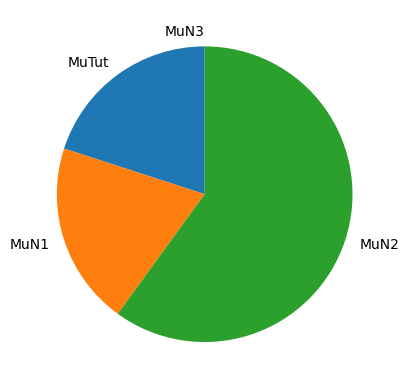

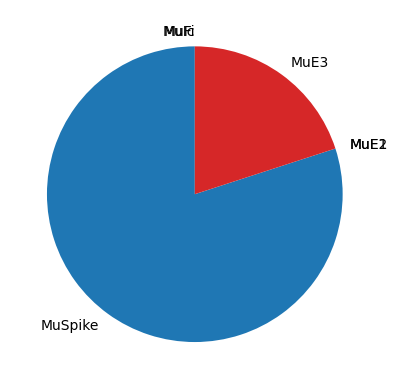

(array([0, 1, 2]),)


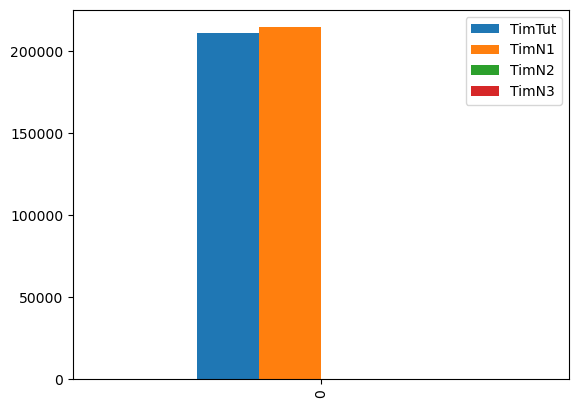

In [ ]:
#Metrica 1
mlabels = ['MuTut','MuN1','MuN2','MuN3']
#auxdf = pd.DataFrame(columns = mlabels)
ar = [sum(singleDf['MuTut']), sum(singleDf['MuN1']), sum(singleDf['MuN2']), sum(singleDf['MuN3'])]
#auxdf.loc[0] = ar
#auxdf
#max = auxdf.plot(y=['MuTut','MuN1','MuN2','MuN3'], kind='bar')
if(np.count_nonzero(ar)!=0):
      plt.pie(ar, labels = mlabels, startangle = 90)
      plt.show()

#Metrica 3
mlabels = ['MuSpike', 'MuE1', 'MuE2', 'MuE3', 'MuFi', 'MuIc']
ar = [sum(singleDf['MuSpike']), sum(singleDf['MuE1']), sum(singleDf['MuE2']), sum(singleDf['MuE3']), sum(singleDf['MuFi']), sum(singleDf['MuIc'])]
if(np.count_nonzero(ar)!=0):
      plt.pie(ar, labels = mlabels, startangle = 90)
      plt.show()

#Metrica 4
mlabels = ['TimTut', 'TimN1', 'TimN2', 'TimN3']
ar1=np.array([sum(singleDf['TimTut']),sum(singleDf['TimN1']),sum(singleDf['TimN2']),sum(singleDf['TimN3'])])
ar2 = np.array([len(singleDf[singleDf['TimTut'] != 0]),len(singleDf[singleDf['TimN1'] != 0]),len(singleDf[singleDf['TimN2'] != 0]),len(singleDf[singleDf['TimN3'] != 0])])
ar2[ar2==0]=1
ar=ar1/ar2
auxdf = pd.DataFrame(columns = mlabels)
auxdf.loc[0] = ar
max = auxdf.plot(y=['TimTut', 'TimN1', 'TimN2', 'TimN3'], kind='bar')
plt.show()

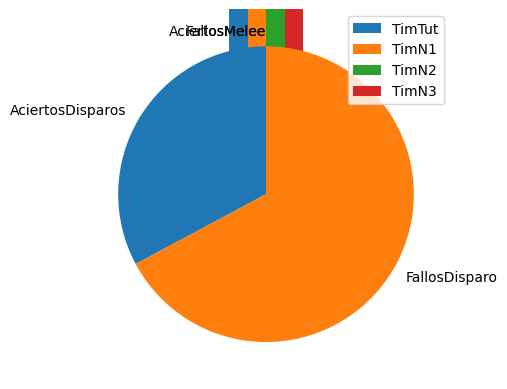

In [6]:
#Metrica 5 y 6
mlabels = ['AciertosDisparos', 'FallosDisparo', 'AciertosMelee', 'FallosMelee']
ar = [sum(singleDf['DisAc']), sum(singleDf['Dis']) - sum(singleDf['DisAc']), 
      sum(singleDf['MelAc']), sum(singleDf['Mel']) - sum(singleDf['MelAc'])]
plt.pie(ar, labels = mlabels, startangle = 90)
plt.show()

#Metrica 7
mlabels = ['DamTut','DamN1','DamN2','DamN3']
auxdf = pd.DataFrame(columns = mlabels)
ar = [sum(singleDf['DamTut']), sum(singleDf['DamN1']), sum(singleDf['DamN2']), sum(singleDf['DamN3'])]
auxdf.loc[0] = ar
max = auxdf.plot(y=['DamTut','DamN1','DamN2','DamN3'], kind='bar')

In [7]:
#Metrica 8
mlabels = ['DamE1', 'DamE2', 'DamE3', 'DamFi', 'DamIc']
ar = [sum(singleDf['DamE1']), sum(singleDf['DamE2']), sum(singleDf['DamE3']), sum(singleDf['DamFi']), sum(singleDf['DamIc'])]
auxdf = pd.DataFrame(columns = mlabels)
auxdf.loc[0] = ar
max = auxdf.plot(y=['DamE1', 'DamE2', 'DamE3', 'DamFi', 'DamIc'], kind='bar')